In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from bayes_opt import BayesianOptimization
from models import CondSM

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


I_s: 0.032887909561395645


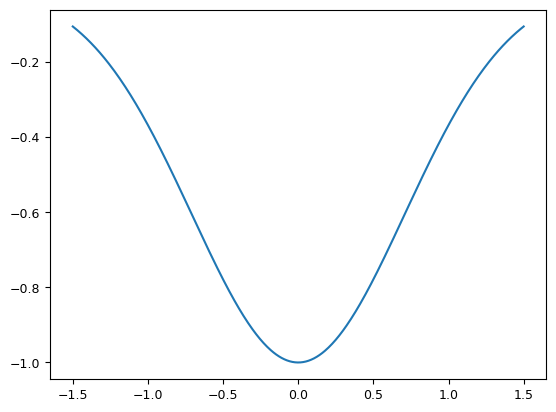

In [17]:
def normalize_over_range(x):
    
    z = (x - x.mean()) / (x.std() + 1e-8) 
    
    return z

def forward_whole_range(model, param_list, input_idx, v_min, v_max, N):

    in_range = torch.linspace(v_min, v_max, N).unsqueeze(1)

    c_volt = torch.tensor(param_list, dtype=torch.float32).expand(N, -1)
    c_volt_l = c_volt[:, :input_idx]
    c_volt_r = c_volt[:, input_idx:]

    input_tensor = torch.cat([c_volt_l, in_range, c_volt_r], dim=1)

    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().numpy()

    return y_out
    
def mse_loss_normalized(x, y):

    x = x.float()
    y = y.float()
    x_norm = (x - x.mean()) / (x.std(unbiased=False) + 1e-8)
    y_norm = (y - y.mean()) / (y.std(unbiased=False) + 1e-8)
    
    mse = torch.mean((y_norm - x_norm)**2).item()

    return mse

def corr_coeff(x, y):
    x = x.float()
    y = y.float()
    xm = x - x.mean()
    ym = y - y.mean()
    num = (xm * ym).mean()
    den = xm.std(unbiased=False) * ym.std(unbiased=False) + 1e-8
    return (num / den).item()  # in [-1, 1], unitless

def mse_loss(x, y):
    
    x = x.float()
    y = y.float()
    
    mse = torch.mean((y - x)**2).item()

    return mse

state_dict = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/grad_away_1e7/sm_grad_away_1e7_baseline_0.pth", weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model.eval()

v_min = -1.5
v_max = 1.5

N = 500
input_range = torch.linspace(v_min, v_max, N).unsqueeze(1)

input_idx = 0

# --- Number of control electrodes (Normally input dim of SM minus 1) --- #
d = model.layer_dims[0] - 1
pbounds = {
    f'x{i}': (v_min, v_max) for i in range(d)
}
# rough amplitude estimate from random controls
def estimate_scale(k=50):
    vals = []
    for _ in range(k):
        cv_list = [np.random.uniform(v_min, v_max) for _ in range(d)]
        cv_t = torch.tensor(cv_list, dtype=torch.float32).expand(N, -1)
        cv_t_l = cv_t[:, :input_idx]
        cv_t_r = cv_t[:, input_idx:]
        input_tensor = torch.cat([cv_t_l, input_range, cv_t_r], dim=1)
        with torch.no_grad():
            I_mu = model(input_tensor)[..., 0]
        vals.append(I_mu.abs().max().item())
    return np.median(vals)

I_scale = estimate_scale()
print(f'I_s: {I_scale}')

def target_function(x):

    m = nn.Sigmoid()
    #return m(5*x)
    return -torch.exp(-1*x**2)#m(x)#torch.sigmoid(5*x)
    #return np.sqrt(1 + (5*x) ** 2)
    #return np.sin(2*x)

target = target_function(input_range)
lam = 0

def f(**kwargs):

    cv_list = [kwargs[f'x{i}'] for i in range(d)]
    c_volt_vec = np.array(cv_list)
    cv_t = torch.tensor(cv_list, dtype=torch.float32).expand(N, -1)
    cv_t_l = cv_t[:, :input_idx]
    cv_t_r = cv_t[:, input_idx:]

    input_tensor = torch.cat([cv_t_l, input_range, cv_t_r], dim=1)
    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor).detach()

    #loss = mse_loss_normalized(y_out, target) + lam * float(np.dot(c_volt_vec, c_volt_vec))
    #loss = mse_loss_normalized(y_out, target) + lam * np.linalg.norm(c_volt_vec, ord=2)
    loss = mse_loss_normalized(y_out, target) + lam * float(np.sum(np.abs(c_volt_vec))) 
    #loss = corr_coeff(target, y_out)
    #loss = -torch.mean((target - y_out)**2).item()
    
    return -loss

"""def f_with_scaling_and_offset(**kwargs):

    cv_list = [kwargs[f'x{i}'] for i in range(d)]
    scale = kwargs['scale']
    offset = kwargs['offset']
    cv_t = torch.tensor(cv_list, dtype=torch.float32).expand(N, -1)
    cv_t_l = cv_t[:, :input_idx]
    cv_t_r = cv_t[:, input_idx:]

    input_tensor = torch.cat([cv_t_l, input_range, cv_t_r], dim=1)

    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor)

    I_mu = y_out[..., 0].unsqueeze(-1)
    I_mu = I_mu * scale + offset

    loss = mse_loss(I_mu, target)

    return -loss"""

plt.plot(input_range, target_function(input_range))

In [18]:
optimizer = BayesianOptimization(
    f=f,
    pbounds=pbounds,
    verbose=1,
    random_state=np.random.randint(0, 2**31 - 1),
)
optimizer.maximize(
    init_points=20,
    n_iter=150,
)

|   iter    |  target   |    x0     |    x1     |    x2     |    x3     |    x4     |    x5     |
-------------------------------------------------------------------------------------------------
| 6         | -0.163141 | -0.120299 | 0.8773283 | -0.634955 | -0.575540 | 1.2437089 | -0.366847 |
| 14        | -0.118813 | -0.589478 | -0.364902 | -0.822942 | -0.828185 | -1.035284 | 0.2274971 |
| 58        | -0.096951 | -0.472821 | -0.252561 | -0.013424 | -1.068108 | -0.197009 | -0.106155 |
| 59        | -0.045924 | -0.490567 | -0.489336 | 0.8357709 | -1.5      | 1.0826418 | -0.385673 |


In [22]:
best_params = optimizer.max['params']
second_optimizer = BayesianOptimization(f=f, pbounds=pbounds, verbose=1)#, random_state=0)

second_optimizer.probe(params=best_params, lazy=False)
second_optimizer.maximize(init_points=25, n_iter=100)

|   iter    |  target   |    x0     |    x1     |    x2     |    x3     |    x4     |    x5     |
-------------------------------------------------------------------------------------------------


[-0.4905671465097853, -0.48933665513126745, 0.8357709428794332, -1.5, 1.0826418837104173, -0.3856730095236578]


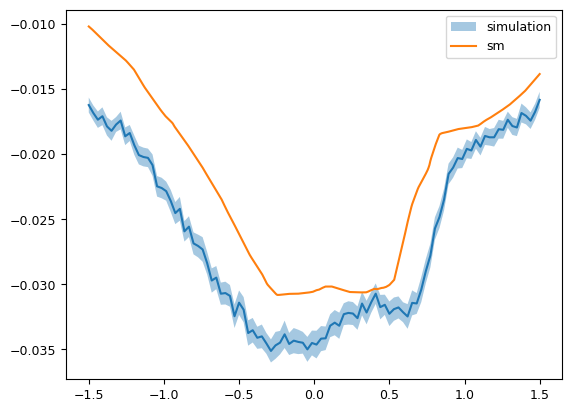

In [30]:
#opt_vals = list(second_optimizer.max['params'].values())
opt_vals = list(optimizer.max['params'].values())
print(np.array(opt_vals).tolist())

y_out = forward_whole_range(model, opt_vals, input_idx, v_min, v_max, N)
#y_out = y_out[..., 0].reshape(-1, 1)<

y_sc = normalize_over_range(y_out)
t_sc = normalize_over_range(target)

data = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/sm_vmb_away_rbf.npz")
I_sc = data['current'] / 1.602176634e-19#normalize_over_range(data['current'] / 1.602176634e-19)
I_err = data['sem'] / 1.602176634e-19

plt.plot(np.linspace(-1.5, 1.5, 100), I_sc)
plt.fill_between(np.linspace(-1.5, 1.5, 100), I_sc-1.96*I_err, I_sc+1.96*I_err, label='simulation', alpha=.4)
plt.plot(input_range, y_out, label='sm')
#plt.plot(input_range, t_sc, label='target')
#plt.plot(input_range, y_out)
plt.legend()

In [29]:
def multiple_runs(num_runs, num_iter=100):
    opt_param_list = []
    target_list = []
    for i in range(num_runs):
        optimizer = BayesianOptimization(
            f=f,
            pbounds=pbounds,
            verbose=0,
            random_state=i,
        )
        optimizer.maximize(
            init_points=10,
            n_iter=10,
        )
        opt_param_list.append(np.array(list(optimizer.max['params'].values())).tolist())
        target_list.append(float(optimizer.max['target']))
        
        print(f'{i+1}/{num_runs} | Params: {opt_param_list[i]}')
    
    opt_param_arr = np.stack(opt_param_list)
    target_arr = np.stack(target_list)

    return opt_param_arr, target_arr

params, targets = multiple_runs(num_runs=5, num_iter=100)

1/5 | Params: [-1.5, -1.5, -0.40974578702232173, -1.5, -0.5062652929107605, 0.7130867756290937]
2/5 | Params: [-0.6366739842409538, -1.109914283645167, -1.4418991263891088, 0.5365065988196731, -0.8651156519998229, -0.7033600218833214]
3/5 | Params: [-1.1185200848961676, 0.29023592693578726, -0.8219639981872924, -1.179162947070051, -0.8390813787883209, -0.4505211449901023]
4/5 | Params: [-1.5, -1.3002610332001303, -1.5, 0.4075340474560323, -0.28931030156055365, -0.8447258467804718]
5/5 | Params: [1.5, 1.4688753531823546, 0.9493433290511059, 1.5, 1.5, -1.3473200254669648]


best loss: -0.29351797699928284
Total points: 100  Near-optimal: 100


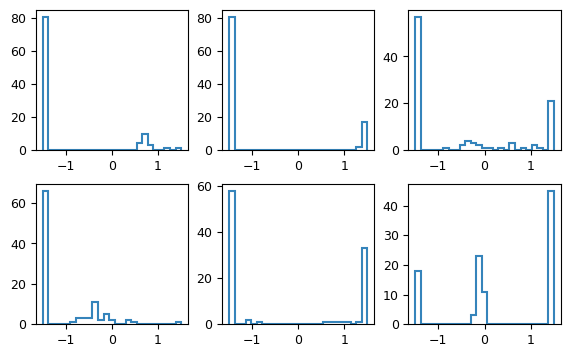

In [47]:
out = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_cubic_vMB_cubic.npy', allow_pickle=True)
data = out.item()
X = data['params']
t = data['targets']

best_loss = t.min()
print(f'best loss: {best_loss}')

margin = 1.5
loss_th = best_loss + margin

mask = t <= loss_th
X_good = X[mask]
t_good = t[mask]
print("Total points:", len(t), " Near-optimal:", len(t_good))

x_ticks= np.arange(-1.5, 1.5, 0.75)

nrows = 2
ncols = d // 2
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(width_in_pt, height_in_pt), constrained_layout=True)

for a in axs:
    a.set_box_aspect(1)
    a.set_xlim(left=-1.5, right=1.5)

for i in range(nrows*ncols):
    ax[i // 3, i % 3].hist(X_good[:, i], bins=25, histtype='step', lw=1.5, alpha=.9)

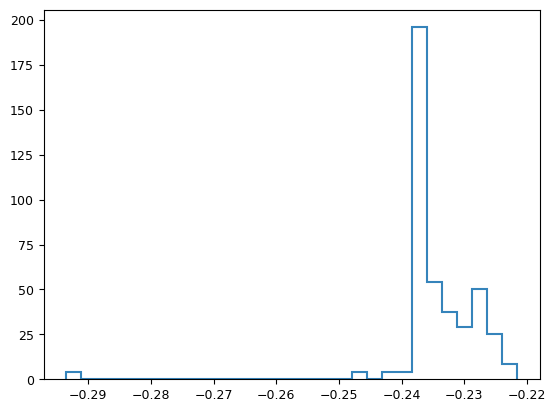

In [48]:
plt.hist(t, bins=30, density=True, histtype='step', lw=1.5, alpha=.9)
plt.show()

In [20]:
from sklearn.cluster import KMeans, DBSCAN

kmeans = KMeans(n_clusters=6, random_state=0, n_init='auto').fit(X)
dbscan = DBSCAN(eps=0.3, min_samples=2).fit(X)

labels_kmeans = kmeans.labels_
labels_dbscan = dbscan.labels_

unique_labels_kmeans = set(labels_kmeans)
unique_labels_dbscan = set(labels_dbscan)

if -1 in unique_labels_dbscan:
    unique_labels_dbscan.remove(-1)

M_kmeans = len(unique_labels_kmeans)
M_dbscan = len(unique_labels_dbscan)
print(f'Multiplicity kmeans: {M_kmeans}')
print(f'Multiplicity dbscan: {M_dbscan}')

from collections import defaultdict

kmeans_clusters = defaultdict(list)
for V, label in zip(X, labels_kmeans):
    if label == -1:
        continue
    kmeans_clusters[label].append(V)
    
for label, points in kmeans_clusters.items():
    pts = np.array(points)
    center = pts.mean(axis=0)
    # cluster "diameter" (max distance between any two points)
    dists = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
    diameter = dists.max()
    print(f"Cluster {label}: n={len(pts)}, diameter={diameter}")

dbscan_clusters = defaultdict(list)
for V, label in zip(X, labels_dbscan):
    if label == -1:
        continue
    dbscan_clusters[label].append(V)
    
for label, points in dbscan_clusters.items():
    pts = np.array(points)
    center = pts.mean(axis=0)
    # cluster "diameter" (max distance between any two points)
    dists = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
    diameter = dists.max()
    print(f"Cluster {label}: n={len(pts)}, diameter={diameter}")

Multiplicity kmeans: 6
Multiplicity dbscan: 8
Cluster 3: n=59, diameter=1.8390489648172148
Cluster 5: n=6, diameter=0.7212219942296186
Cluster 0: n=38, diameter=1.9998838163306825
Cluster 1: n=80, diameter=1.3708731297520624
Cluster 4: n=16, diameter=1.7579845528032416
Cluster 2: n=1, diameter=0.0
Cluster 0: n=2, diameter=0.0685537226485986
Cluster 1: n=31, diameter=0.49359264915586526
Cluster 2: n=127, diameter=1.72015753924713
Cluster 3: n=3, diameter=0.26864475763907686
Cluster 4: n=4, diameter=0.44377445571072904
Cluster 5: n=2, diameter=0.1981575421331729
Cluster 6: n=4, diameter=0.4756101518248182
Cluster 7: n=3, diameter=0.30717115169473064


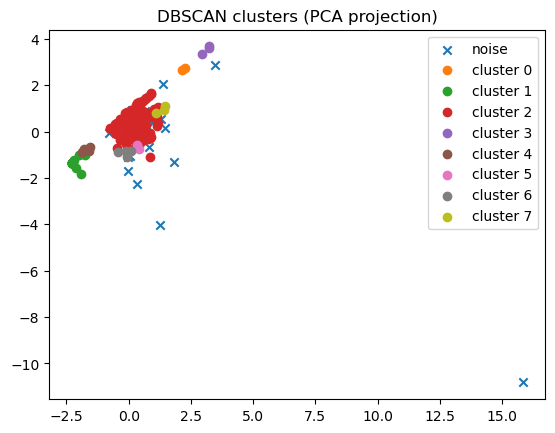

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_good_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_good_scaled)

plt.figure()
for lab in np.unique(labels_dbscan):
    mask = labels_dbscan == lab
    if lab == -1:
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], marker='x', label='noise')
    else:
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=f'cluster {lab}')
plt.legend()
plt.title("DBSCAN clusters (PCA projection)")

plt.show()

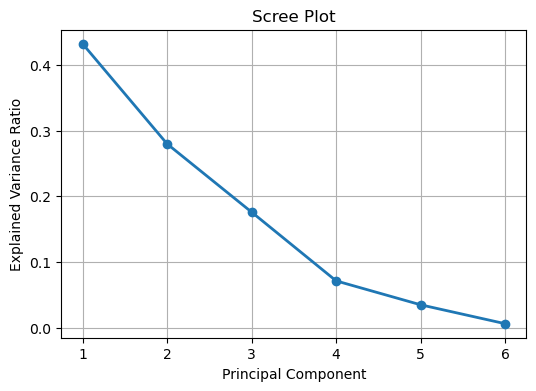

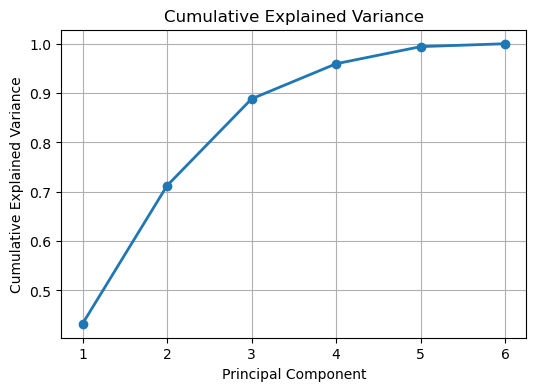

In [14]:
# Fit PCA with all components
pca = PCA()
pca.fit(X_good_scaled)

# Explained variance ratio per component
evr = pca.explained_variance_ratio_
components = np.arange(1, len(evr) + 1)

# Scree plot (per-component)
plt.figure(figsize=(6,4))
plt.plot(components, evr, 'o-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

# (Optional) cumulative explained variance
plt.figure(figsize=(6,4))
plt.plot(components, np.cumsum(evr), 'o-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.grid(True)
plt.show()